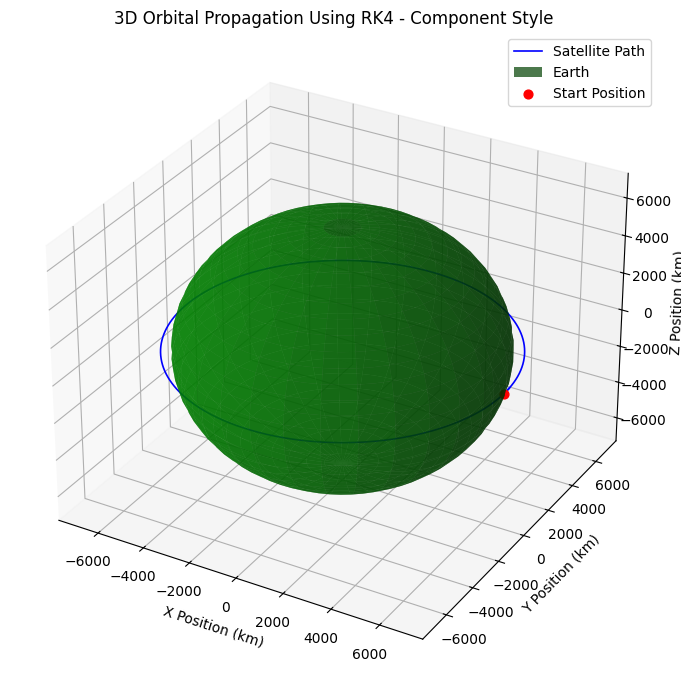

In [13]:
# Relevant Python Libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulation Parameters
MU = 3.986004418e14       # Earth's gravitational parameter (m^3/s^2)
EARTH_RADIUS = 6371000    # metres
initial_altitude = 400000 # metres
initial_velocity = 767000 # m/s
dt = 10                   # Time step (seconds)
duration = 5600           # Total propagation time (seconds)
steps = int(duration / dt)

# Defining Acceleration Function
def get_accel(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    ax = -MU * x / r**3
    ay = -MU * y / r**3
    az = -MU * z / r**3
    return ax, ay, az

# Defining RK4 Step Function (Component Style)
def rk4_step(dt, x, y, z, vx, vy, vz):
    # First Slopes: k1
    k1_vx, k1_vy, k1_vz = get_accel(x, y, z)
    k1_x, k1_y, k1_z = vx, vy, vz

    # Second Slopes: k2
    k2_vx, k2_vy, k2_vz = get_accel(x + (dt/2)*k1_x, y + (dt/2)*k1_y, z + (dt/2)*k1_z)
    k2_x, k2_y, k2_z = vx + (dt/2)*k1_vx, vy + (dt/2)*k1_vy, vz + (dt/2)*k1_vz

    # Third Slopes: k3
    k3_vx, k3_vy, k3_vz = get_accel(x + (dt/2)*k2_x, y + (dt/2)*k2_y, z + (dt/2)*k2_z)
    k3_x, k3_y, k3_z = vx + (dt/2)*k2_vx, vy + (dt/2)*k2_vy, vz + (dt/2)*k2_vz

    # Fourth Slopes: k4
    k4_vx, k4_vy, k4_vz = get_accel(x + dt*k3_x, y + dt*k3_y, z + dt*k3_z)
    k4_x, k4_y, k4_z = vx + dt*k3_vx, vy + dt*k3_vy, vz + dt*k3_vz

    # Final Weighted Average
    # Position Update
    x_new  = x  + (dt/6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    y_new  = y  + (dt/6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    z_new  = z  + (dt/6) * (k1_z + 2*k2_z + 2*k3_z + k4_z)
    # Velocity Update
    vx_new = vx + (dt/6) * (k1_vx + 2*k2_vx + 2*k3_vx + k4_vx)
    vy_new = vy + (dt/6) * (k1_vy + 2*k2_vy + 2*k3_vy + k4_vy)
    vz_new = vz + (dt/6) * (k1_vz + 2*k2_vz + 2*k3_vz + k4_vz)

    return x_new, y_new, z_new, vx_new, vy_new, vz_new


# Initial Position And Velocity (Using the ISS-like orbit: 400km altitude)
x, y, z = EARTH_RADIUS + 400000, 0, 0  # Satellite Position from Centre of Earth (metres)
vx, vy, vz = 0, 7670, 0                # Orbital Velocity in m/s

# Arrays to store results for plotting
x_hist, y_hist, z_hist = [x], [y], [z]

# Simulation
for _ in range(steps):
    x, y, z, vx, vy, vz = rk4_step(dt, x, y, z, vx, vy, vz)
    x_hist.append(x)
    y_hist.append(y)
    z_hist.append(z)
   
# Visualization
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(np.array(x_hist)/1000, np.array(y_hist)/1000, color='blue', linewidth=1.2, label="Satellite Path")

u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
ax.plot_surface(EARTH_RADIUS/1000 * np.cos(u) * np.sin(v),
                EARTH_RADIUS/1000 * np.sin(u) * np.sin(v),
                EARTH_RADIUS/1000 * np.cos(v), color='green', alpha=0.7, zorder=0, label="Earth")

ax.scatter(*[x_hist[0]/1000], *[y_hist[0]/1000], *[z_hist[0]/1000],
           color='red', s=40, zorder=5, label="Start Position")

ax.set_xlabel("X Position (km)")
ax.set_ylabel("Y Position (km)")
ax.set_zlabel("Z Position (km)")
ax.set_title("3D Orbital Propagation Using RK4 - Component Style")

ax.legend()


ax.grid(True)

plt.tight_layout()
plt.show()